In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

from utils.tools import *

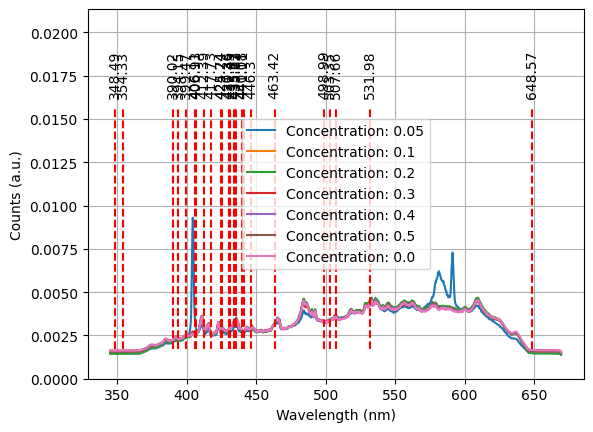

In [ ]:
root = os.getcwd()
method = "RLIBS"
date = "8_4_26"
atom = "Nd_I"
top_n_lines = 5

path = os.path.join(root, method)
path = os.path.join(path, date)
results_path = os.path.join(root, "Results")
results_path = os.path.join(results_path, date)

results = {}
spectral_max = -np.inf
plotted_concentrations = []

fig, ax = plt.subplots(1)

for file in os.listdir(path):
    file_path = os.path.join(path, file)

    wavelength, spectrum = read_spe(file_path)
    total_area = np.trapezoid(spectrum, wavelength)
    spectrum = spectrum / total_area

    if spectral_max < spectrum.max():
        spectral_max = spectrum.max()
    

    concentration = file_to_concentration(file)

    if concentration not in plotted_concentrations:
        ax.plot(wavelength, spectrum, label = f"Concentration: {concentration}")
        plotted_concentrations.append(concentration)

    results[file] = {
        "wavelength": wavelength,
        "spectrum": spectrum,
        "concentration": concentration
    }


lines_df = read_referenece_lines(atom, wavelength, top_n_lines = top_n_lines)

ax.vlines(lines_df["wavelength"], ymin = spectrum.min(), ymax = 1.1 * spectral_max, linestyles = "--", color = "red")

for wl in lines_df["wavelength"]:
    ax.text(wl, 1.15 * spectral_max, f"{round(wl, 2)}", rotation = "vertical", ha = "center")

ax.grid(True)
ax.legend()
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Counts (a.u.)")
ax.set_ylim(0, 1.5 * spectral_max)
plt.show()

In [ ]:
N_points = 21
N_fit = 512
lamb0 = 435.82
fit_method = "voigt"
maxfev = 5000

debug = False

fit_param_names = {
    "gaussian":   ["A", "mu", "sigma", "a", "b"],
    "lorentzian": ["A", "mu", "gamma", "a", "b"],
    "voigt":      ["A", "mu", "sigma", "gamma", "a", "b"],
}


for file in results.keys():
    print("=" * 50)
    print(f"Fitting: {file}")
    print("=" * 50)
    data = results[file]

    x = data["wavelength"]
    y = data["spectrum"]
    idx = np.argmin(np.abs(x - lamb0))
    x = x[idx - N_points // 2 : idx + N_points // 2]
    y = y[idx - N_points // 2 : idx + N_points // 2]

    p0 = initial_guess(x, y, mode = fit_method)
    bounds = set_bounds(x, y, p0, mode = fit_method)

    if fit_method == "gaussian":
        fit_func = gaussian_fit

    elif fit_method == "lorentzian":
        fit_func = lorentzian_fit

    elif fit_method == "voigt":
        fit_func = voigt_fit

    try:
        params, pcov = curve_fit(fit_func, x, y, p0 = p0, bounds = bounds, maxfev = maxfev)
        x_fit = np.linspace(x.min(), x.max(), N_fit)
        y_fit = fit_func(x_fit, *params)

    except Exception as e:
        print(f"An error occurred: {e}")

        fig, ax = plt.subplots(1)
        ax.plot(x, y, "o")
        ax.grid(True)
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Counts (a.u.)")
        ax.set_title(f"Failed Fit: {file}")
        plt.show()
        continue

    if debug:
        fig, ax = plt.subplots(1)
        ax.plot(x, y, "o", color = "black")
        ax.plot(x_fit, y_fit, color = "red")
        ax.grid(True)
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Counts (a.u.)")
        ax.set_title(f"Debug Plot: {file}")
        plt.show()

    area = compute_area(x, params, mode = fit_method)
    results[file]["area"] = area

    y_fit = fit_func(x, *params)
    r2 = compute_r2(y, y_fit)
    results[file]["R2"] = r2
    print(f"R^2: {round(r2, 3)}")

    for name, value in zip(fit_param_names[fit_method], params):
        print(f"{name}: {round(value, 3)}")
        results[file][name] = value
    
    print(f"area: {round(area, 3)}")
    print("=" * 50)

Fitting: rlibs_005_1.SPE
R^2: 0.931
A: 0.016
mu: 437.4
sigma: 1.854
gamma: 1.869
a: -0.0
b: 0.147
area: 0.005
Fitting: rlibs_005_2.SPE
R^2: 0.89
A: 0.021
mu: 437.4
sigma: 2.799
gamma: 1.575
a: -0.0
b: 0.116
area: 0.006
Fitting: rlibs_005_3.SPE
R^2: 0.843
A: 0.019
mu: 436.714
sigma: 3.484
gamma: 1.755
a: -0.0
b: 0.049
area: 0.005
Fitting: rlibs_005_4.SPE
R^2: 0.9
A: 0.018
mu: 437.398
sigma: 2.244
gamma: 1.785
a: -0.0
b: 0.129
area: 0.005
Fitting: rlibs_005_5.SPE
R^2: 0.877
A: 0.024
mu: 437.4
sigma: 1.718
gamma: 1.859
a: -0.001
b: 0.225
area: 0.007
Fitting: rlibs_01_1.SPE
R^2: 0.903
A: 0.026
mu: 437.4
sigma: 2.265
gamma: 1.448
a: -0.0
b: 0.217
area: 0.008
Fitting: rlibs_01_2.SPE
R^2: 0.924
A: 0.026
mu: 437.4
sigma: 2.296
gamma: 1.459
a: -0.0
b: 0.215
area: 0.008
Fitting: rlibs_01_3.SPE
R^2: 0.892
A: 0.03
mu: 437.4
sigma: 2.573
gamma: 1.474
a: -0.0
b: 0.199
area: 0.009
Fitting: rlibs_01_4.SPE
R^2: 0.948
A: 0.026
mu: 437.399
sigma: 2.263
gamma: 1.602
a: -0.0
b: 0.2
area: 0.008
Fitting: rli

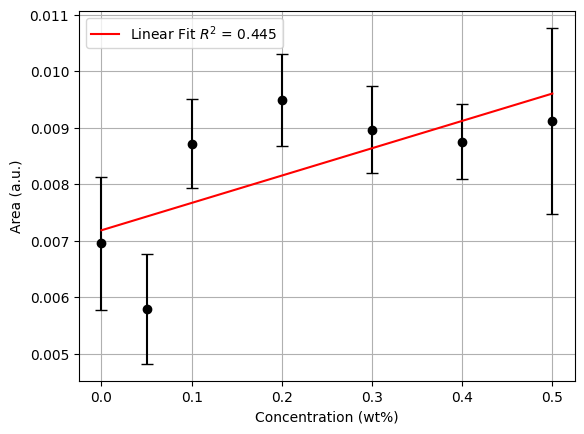

In [ ]:
r2_limit = 0.5

areas = np.array([results[file]["area"] for file in results.keys()])
concentrations = np.array([results[file]["concentration"] for file in results.keys()])
r2_values = np.array([results[file]["R2"] for file in results.keys()])

mask = r2_values >= r2_limit
areas = areas[mask]
concentrations = concentrations[mask]

unique_concentrations, indexes = np.unique(concentrations, return_inverse = True)
mean_areas = np.array([np.mean(areas[indexes == i]) for i in range(len(unique_concentrations))])
std_areas = np.array([np.std(areas[indexes == i], ddof = 1) for i in range(len(unique_concentrations))])

params, _ = curve_fit(linear_fit, unique_concentrations, mean_areas)

areas_fit = linear_fit(unique_concentrations, *params)
r2 = compute_r2(mean_areas, areas_fit)

fig, ax = plt.subplots(1)
ax.errorbar(unique_concentrations, mean_areas, yerr = std_areas, fmt = "o", capsize = 4, color = "black")
ax.plot(unique_concentrations, areas_fit, color = "red", label = f"Linear Fit $R^2$ = {round(r2, 3)}")

ax.grid(True)
ax.legend()
ax.set_xlabel("Concentration (wt%)")
ax.set_ylabel("Area (a.u.)")
plt.show()